# Differential Gene Expression Analysis

여기에 pca, knn, clustering 코드 넣지말고 'spatial_notebook.ipynb' 결과 파일을 사용한다고 적는거 어때?

## VisiumHD

In [ ]:
from stLENS import stLENS
stlens = stLENS()

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data

In [ ]:
stlens_adata = sc.read_h5ad('./output/visiumhd/stlens_adata')
scanpy_adata = sc.read_h5ad('./output/visiumhd/scanpy_adata')

### DEA

In [ ]:
sc.pp.normalize_total(adata_stlens)
sc.pp.log1p(adata_stlens)

In [ ]:
import scanpy as sc

def top3_markers(adata, groupby, target, method="wilcoxon", key="deg"):
    sc.tl.rank_genes_groups(
        stlens,
        groupby=groupby,
        groups=[target],
        reference="rest",
        method=method,
        use_raw=False,     
        key_added=key,
    )
    df = sc.get.rank_genes_groups_df(adata, group=target, key=key)
    df = df.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False])
    return df[["names", "logfoldchanges", "pvals_adj", "scores"]].head(3)

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def _get_gene_vector(adata, gene, use_layer=None):
    X = adata[:, gene].layers[use_layer] if use_layer is not None else adata[:, gene].X
    x = X.toarray().ravel() if hasattr(X, "toarray") else np.asarray(X).ravel()
    return x

def spatial_genes_scanpy_to_pdf_vmax_max(
    adata,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=1.0,
    pdf_path=None,
    show=True,
    cmap="inferno",
):
    genes = [genes] if isinstance(genes, str) else list(genes)
    vmax_dict = {}

    pdf = PdfPages(pdf_path) if pdf_path is not None else None
    try:
        for g in genes:
            expr = _get_gene_vector(adata, g, use_layer=use_layer)
            expr = expr[np.isfinite(expr)]

            vmax_val = float(np.max(expr)) if expr.size else float(vmin)
            if vmax_val <= vmin:
                vmax_val = float(vmin) + 1e-9  

            vmax_dict[g] = vmax_val

            fig = sc.pl.spatial(
                adata,
                color=g,
                layer=use_layer,
                vmin=vmin,
                vmax=vmax_val,    
                spot_size=spot_size,
                show=False,
                return_fig=True,
                cmap=cmap,
            )

            if pdf is not None:
                pdf.savefig(fig)
            if show:
                plt.show(fig)
            plt.close(fig)
    finally:
        if pdf is not None:
            pdf.close()

    return vmax_dict

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import ranksums

def _get_gene_vec(adata, gene):
    X = adata[:, gene].X
    v = X.toarray().ravel() if hasattr(X, "toarray") else np.asarray(X).ravel()
    return v

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

def plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens,
    adata_scanpy,
    genes,
    vmax_dict=None,       
    vmin=0,                
    st_cluster_col="leiden_1.0",
    st_cluster="12",
    sc_cluster_col="leiden_1.0",
    sc_cluster="7",
    color_stlens="#77b5d9",
    color_scanpy="#f4a582",
    cut=0,
    bw="scott",
    inner=None,
    min_n=5,
    show_median_line=True,
    show_median_text=False,
    median_text_fmt="{:.2f}",
    median_text_y_offset=0.03,
    show_pvalue_text=True,
    figsize=(4.8, 4.5),
    title_prefix="",
    pdf_path=None,
    show=True,
):
    genes = [genes] if isinstance(genes, str) else list(genes)
    vmax_dict = {} if vmax_dict is None else dict(vmax_dict)

    m_st = adata_stlens.obs[st_cluster_col].astype(str).eq(str(st_cluster)).to_numpy()
    m_sc = adata_scanpy.obs[sc_cluster_col].astype(str).eq(str(sc_cluster)).to_numpy()

    legend_handles = [
        Patch(facecolor=color_stlens, edgecolor=color_stlens, label="stLENS"),
        Patch(facecolor=color_scanpy, edgecolor=color_scanpy, label="Scanpy"),
    ]

    results = []
    pdf = PdfPages(pdf_path) if pdf_path is not None else None
    try:
        for g in genes:
            if g not in adata_stlens.var_names:
                raise KeyError(f"gene not found in stLENS var_names: {g}")
            if g not in adata_scanpy.var_names:
                raise KeyError(f"gene not found in scanpy var_names: {g}")

            vL = _get_gene_vec(adata_stlens[m_st], g)
            vR = _get_gene_vec(adata_scanpy[m_sc], g)
            vL = vL[np.isfinite(vL)]
            vR = vR[np.isfinite(vR)]

            if (vL.size >= min_n) and (vR.size >= min_n):
                z, pval = ranksums(vL, vR)
                z, pval = float(z), float(pval)
            else:
                z, pval = np.nan, np.nan

            results.append({"gene": g, "n_stlens": int(vL.size), "n_scanpy": int(vR.size),
                            "ranksum_z": z, "pvalue": pval})

            df = pd.DataFrame({
                "expr": np.concatenate([vL, vR]),
                "method": (["stLENS"] * vL.size) + (["Scanpy"] * vR.size),
                "x": [""] * (vL.size + vR.size),
            })

            fig, ax = plt.subplots(figsize=figsize)

            sns.violinplot(
                data=df, x="x", y="expr", hue="method",
                split=True, cut=cut, bw=bw, inner=inner, linewidth=1.0,
                palette={"stLENS": color_stlens, "Scanpy": color_scanpy},
                ax=ax,
            )

            if g in vmax_dict and np.isfinite(vmax_dict[g]):
                ax.set_ylim(vmin, float(vmax_dict[g]))

            if show_median_line:
                medL = float(np.nanmedian(vL)) if vL.size else np.nan
                medR = float(np.nanmedian(vR)) if vR.size else np.nan

                center = 0.0
                left_x0, left_x1 = center - 0.15, center - 0.01
                right_x0, right_x1 = center + 0.01, center + 0.15

                if np.isfinite(medL):
                    ax.hlines(medL, left_x0, left_x1, colors="black", linewidth=1.2)
                if np.isfinite(medR):
                    ax.hlines(medR, right_x0, right_x1, colors="black", linewidth=1.2)

                if show_median_text:
                    y0, y1 = ax.get_ylim()
                    dy = median_text_y_offset * (y1 - y0)
                    xL = 0.5 * (left_x0 + left_x1)
                    xR = 0.5 * (right_x0 + right_x1)
                    if np.isfinite(medL):
                        ax.text(xL, medL + dy, median_text_fmt.format(medL),
                                ha="center", va="bottom", fontsize=10)
                    if np.isfinite(medR):
                        ax.text(xR, medR + dy, median_text_fmt.format(medR),
                                ha="center", va="bottom", fontsize=10)

            if show_pvalue_text:
                if np.isfinite(pval):
                    star = p_to_star(pval)
                    txt = f"p={pval:.2e} ({star})"
                else:
                    txt = "p=NA"
                ax.text(0.02, 0.98, txt, transform=ax.transAxes,
                        ha="left", va="top", fontsize=10)

            ax.set_xlabel("")
            ax.set_ylabel("Gene Expression")
            ax.set_title(f"{title_prefix}{g}".strip())

            if ax.legend_ is not None:
                ax.legend_.remove()
            ax.legend(handles=legend_handles, frameon=False, loc="upper right")

            fig.tight_layout()

            if pdf is not None:
                pdf.savefig(fig)
            if show:
                plt.show()
            plt.close(fig)
    finally:
        if pdf is not None:
            pdf.close()

    return results

In [ ]:
target_name = "Proliferating Immune II"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
16797,MT-CO3,-2.317699,6.111302e-172,-28.298187
16796,MT-CO2,-2.716739,3.500842e-166,-27.801432
16795,MT-ATP6,-2.274756,2.038357e-162,-27.473503


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


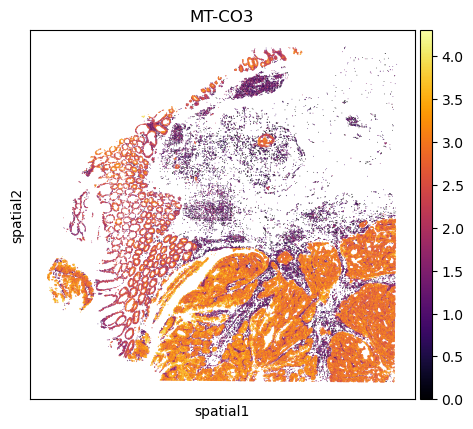

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


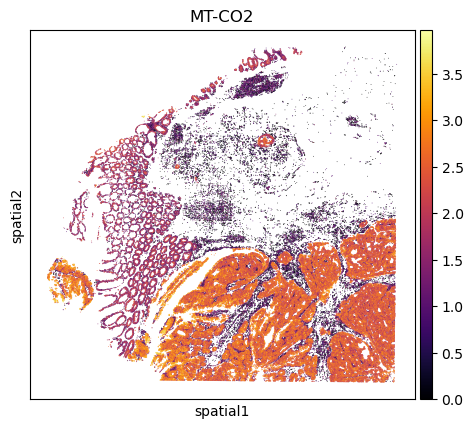

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


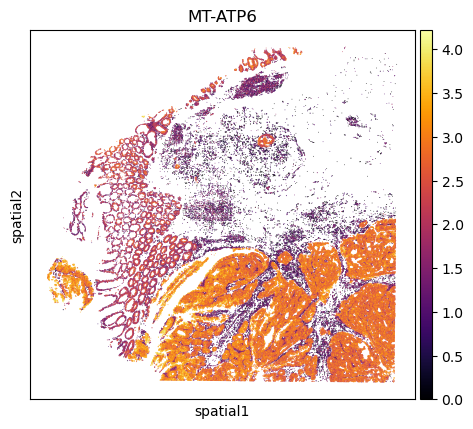

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_proimmune.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


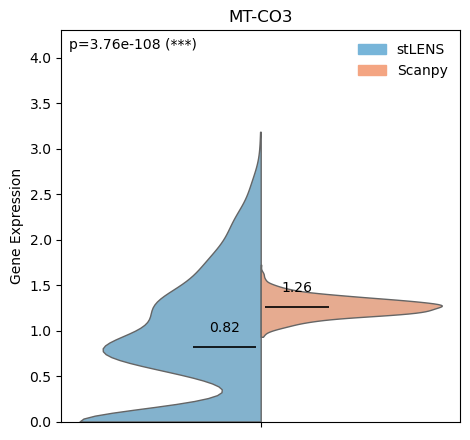

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


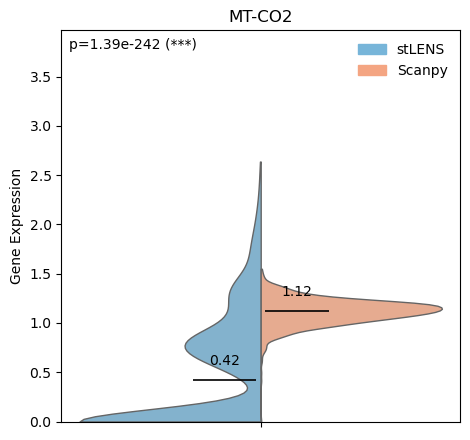

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


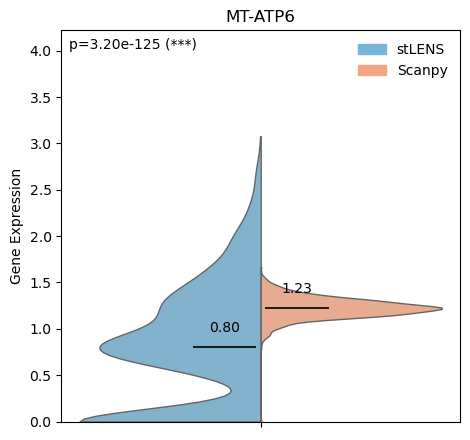

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_1.0",
    st_cluster="16",
    sc_cluster_col="leiden_5.0",
    sc_cluster="34",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_proimmune.pdf",
    show=True,
)

In [ ]:
target_name = "Macrophage"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
7,APOE,4.650747,0.0,40.923203
1,LYZ,4.046784,0.0,51.545124
3,IFI30,3.990129,0.0,43.503204


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


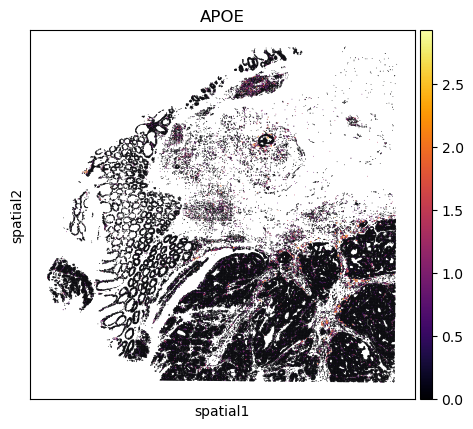

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


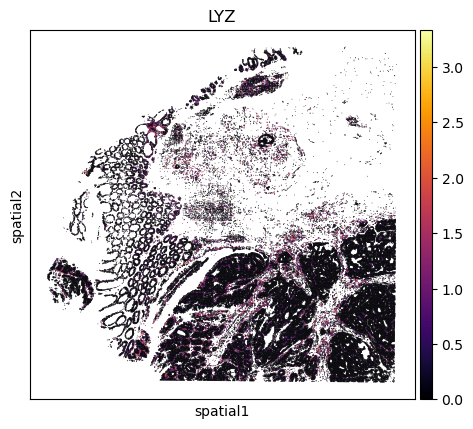

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


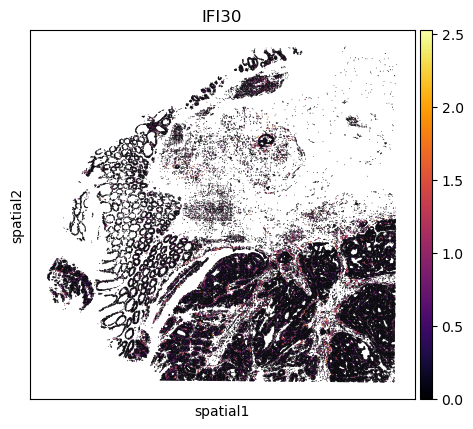

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_macro.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


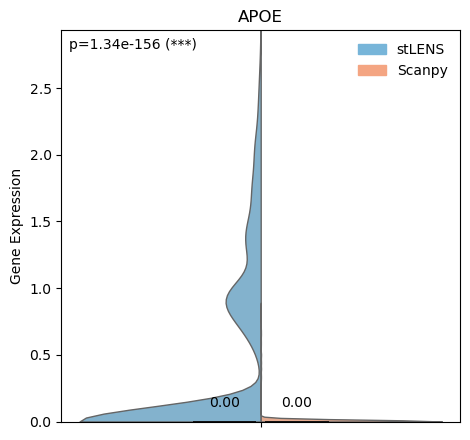

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


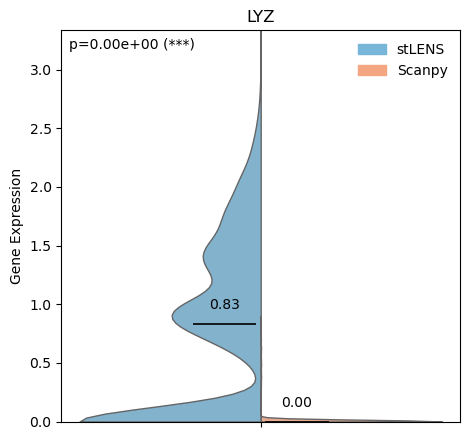

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


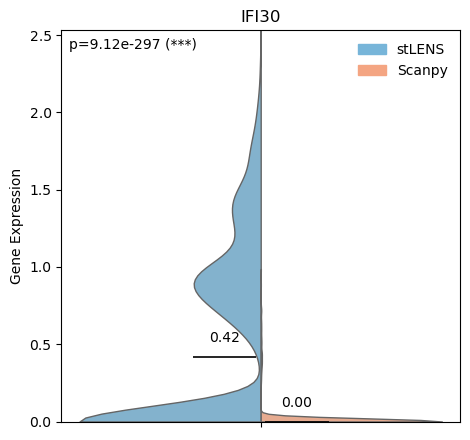

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_1.5",
    st_cluster="11",
    sc_cluster_col="leiden_3.0",
    sc_cluster="21",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_macro.pdf",
    show=True,
)

In [ ]:
target_name = "Endothelial"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
8,VWF,6.277076,0.0,43.353687
4,PECAM1,5.430303,0.0,55.519226
2,ENG,4.922777,0.0,56.241806


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


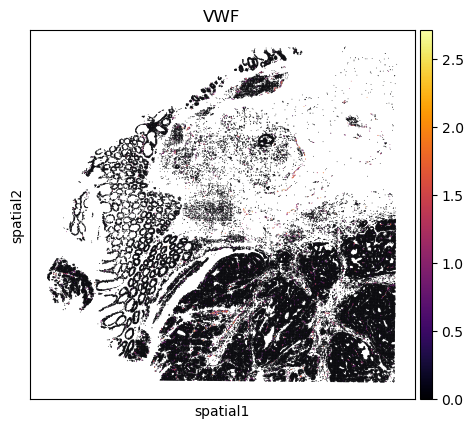

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


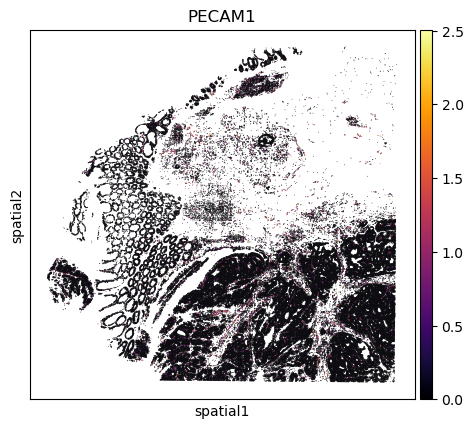

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


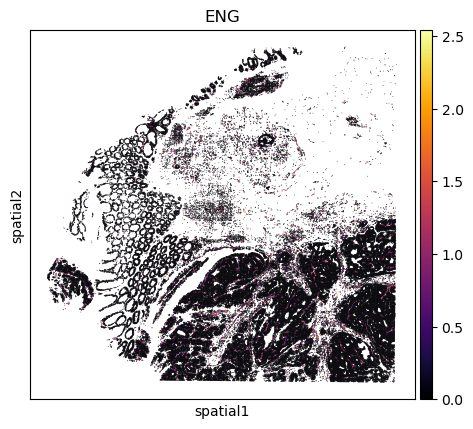

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_endo.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


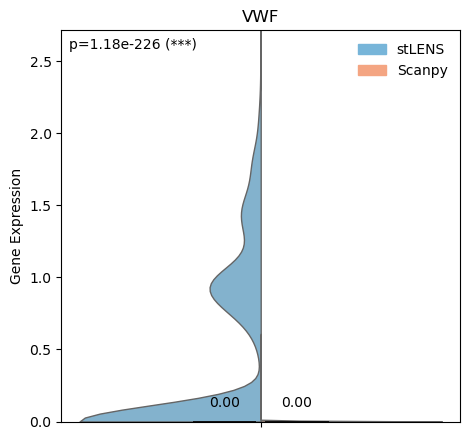

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


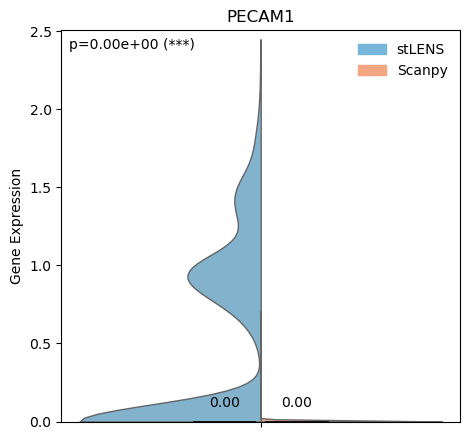

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


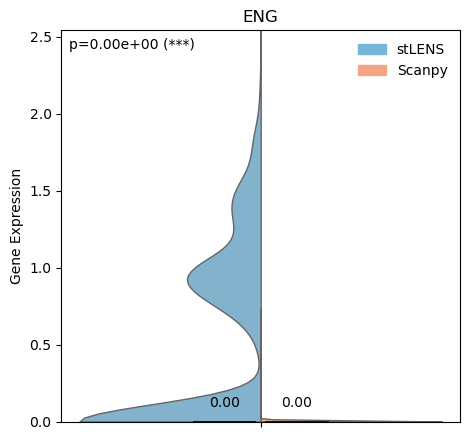

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_3.0",
    st_cluster="18",
    sc_cluster_col="leiden_4.5",
    sc_cluster="8",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_endo.pdf",
    show=True,
)

In [ ]:
target_name = "Enterocyte"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
10,CEACAM7,8.216117,0.0,64.610184
14,GUCA2A,7.156875,0.0,56.369209
9,SLC26A2,5.823185,0.0,70.672485


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


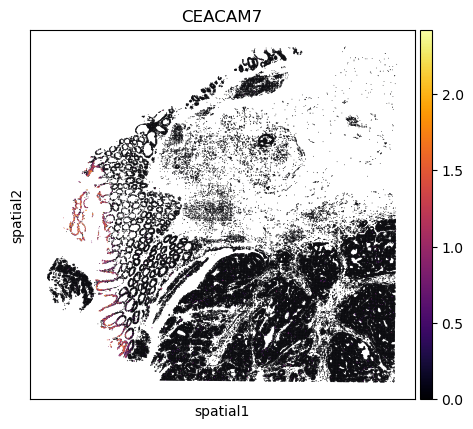

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


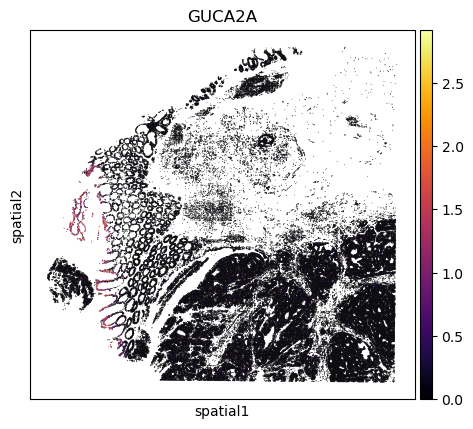

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


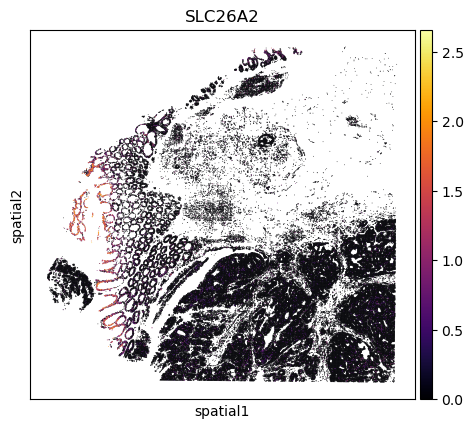

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_entero.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


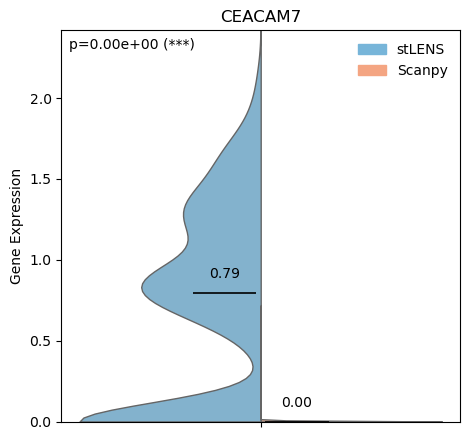

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


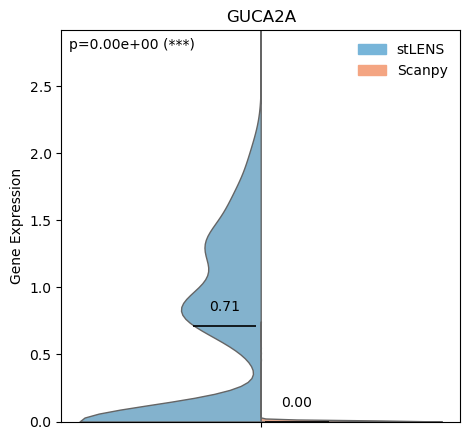

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


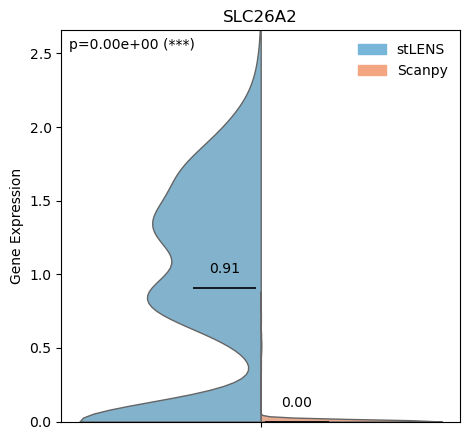

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_0.5",
    st_cluster="9",
    sc_cluster_col="leiden_4.0",
    sc_cluster="23",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_entero.pdf",
    show=True,
)

In [ ]:
target_name = "Goblet"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
24,ITLN1,7.637721,0.0,44.338085
9,MUC5B,7.431868,0.0,81.390388
6,SPINK4,6.857409,0.0,98.073257


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


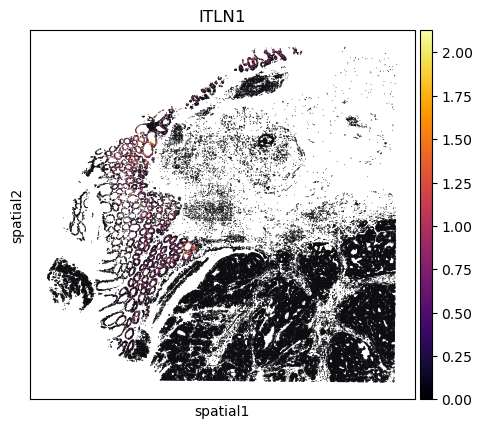

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


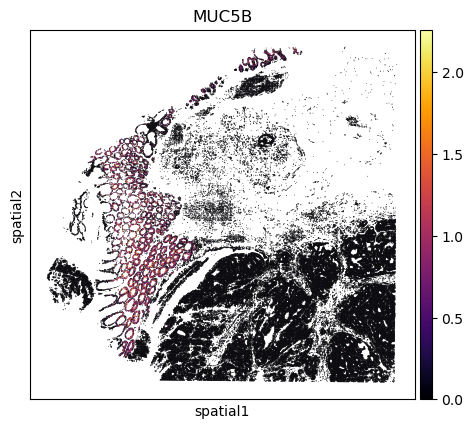

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


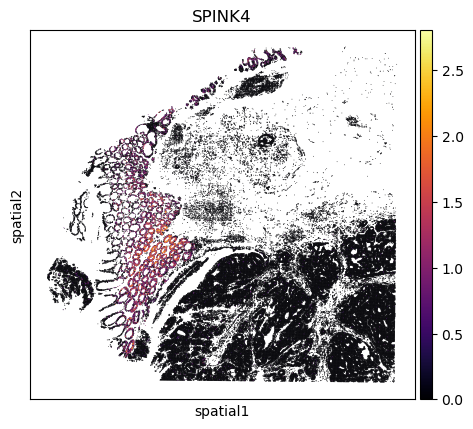

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_goblet.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


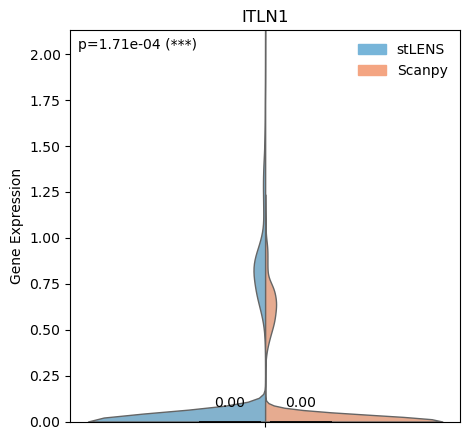

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


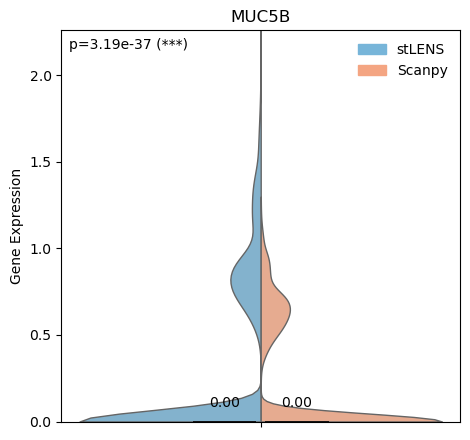

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


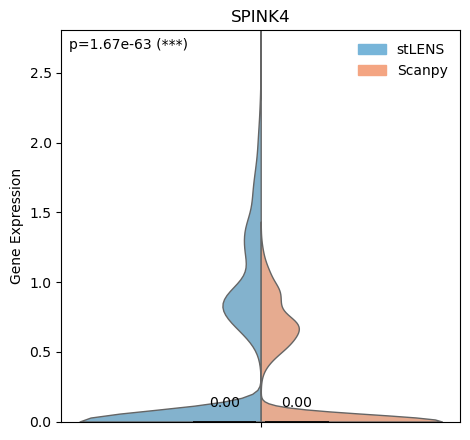

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_0.5",
    st_cluster="2",
    sc_cluster_col="leiden_0.5",
    sc_cluster="3",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_goblet.pdf",
    show=True,
)

In [ ]:
target_name = "Proliferating Fibroblast"

top3 = top3_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)
top3

,names,logfoldchanges,pvals_adj,scores
0,COL3A1,3.759072,0.0,59.259075
1,COL1A1,3.572432,0.0,55.107849
2,COL1A2,3.501957,0.0,53.787956


In [ ]:
genes = top3["names"].tolist()

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


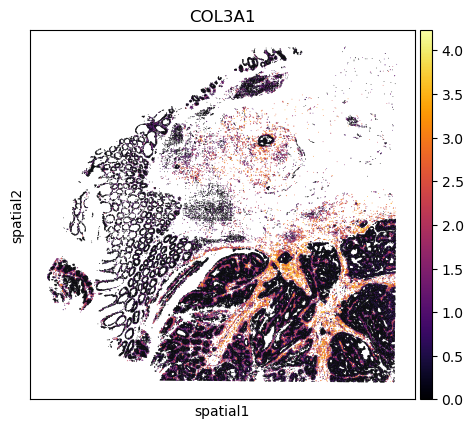

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


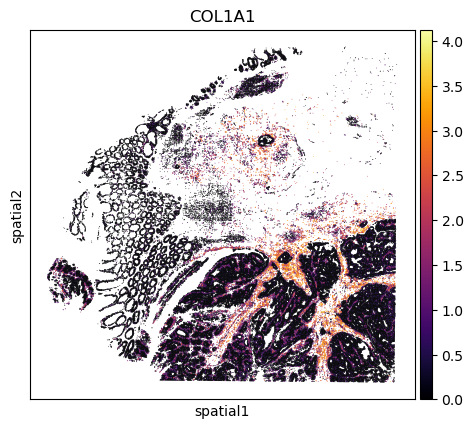

/tmp/ipykernel_3119142/3641022755.py:36: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


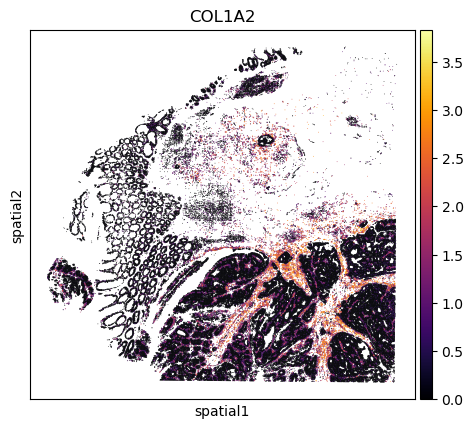

In [ ]:
vmax_dict = spatial_genes_scanpy_to_pdf_vmax_max(
    adata_stlens,
    genes,
    use_layer=None,
    vmin=0,
    spot_size=50,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/markergene_profib.pdf",
    show=True,
)

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


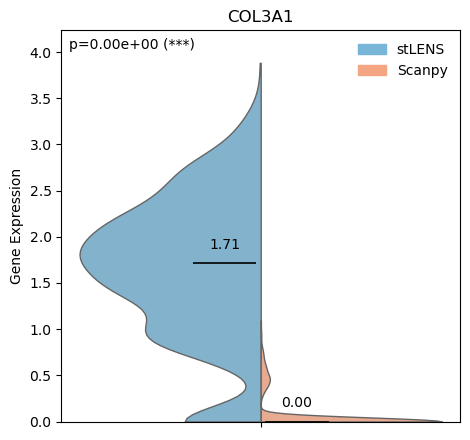

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


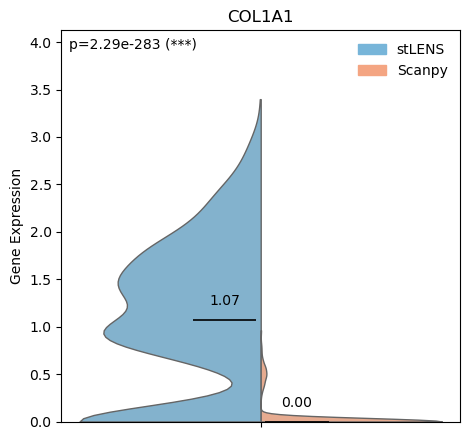

/tmp/ipykernel_3119142/1286208987.py:94: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


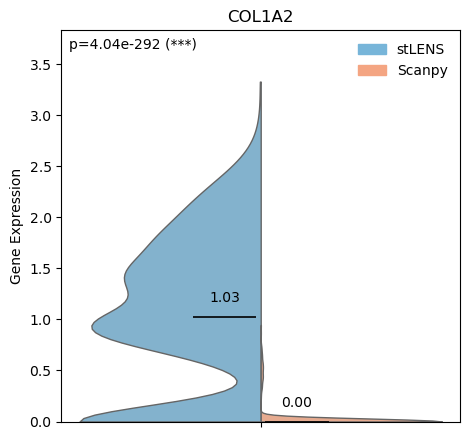

In [ ]:
res = plot_split_violins_per_gene_seaborn_ranksum(
    adata_stlens=adata_stlens,
    adata_scanpy=adata_scanpy,
    genes=genes,
    vmax_dict=vmax_dict,   
    vmin=0,
    st_cluster_col="leiden_5.0",
    st_cluster="33",
    sc_cluster_col="leiden_4.5",
    sc_cluster="32",
    cut=0,
    show_median_line=True,
    show_median_text=True,
    show_pvalue_text=True,
    pdf_path="/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation/violin_profib.pdf",
    show=True,
)

#### Tumor

In [ ]:
target_name = "Tumor I"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['IGKC',
 'MT-ND2',
 'TMSB4X',
 'KCNK3',
 'GRM3',
 'UGT1A5',
 'OR1D2',
 'SLC36A2',
 'SLC12A1',
 'CCDC160']

In [ ]:
sc.tl.score_genes(test_adata, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_score_1.pdf"


sc.pl.spatial(
    test_adata,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/4242284902.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [ ]:
target_name = "Tumor II"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['DPEP1',
 'REG1A',
 'LY6G6D',
 'MUC17',
 'FGGY',
 'PRAP1',
 'KRT23',
 'ALDOB',
 'ANPEP',
 'DMBT1']

In [ ]:
sc.tl.score_genes(test_adata, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_score_2.pdf"


sc.pl.spatial(
    test_adata,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1483605772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [ ]:
target_name = "Tumor III"

top10 = top3_markers_temp(test_adata, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['OLFM4',
 'CEACAM5',
 'COL3A1',
 'VIM',
 'MT-CYB',
 'B2M',
 'TMSB4X',
 'DMBT1',
 'REG1A',
 'COL1A1']

In [ ]:
# test_adata.var_names_make_unique()

In [ ]:
sc.tl.score_genes(test_adata, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_score_3.pdf"


sc.pl.spatial(
    test_adata,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1418711188.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [ ]:
target_name = "Tumor IV"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['MT-ATP6',
 'MT-ND3',
 'IGKC',
 'MT-CYB',
 'MT-CO3',
 'MT-CO2',
 'IGHG1',
 'MT-ND2',
 'MT-ND1',
 'MT-ND4']

In [ ]:
sc.tl.score_genes(test_adata, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_score_4.pdf"


sc.pl.spatial(
    test_adata,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1033028183.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


In [ ]:
target_name = "Tumor V"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['S100A6',
 'OLFM4',
 'KRT8',
 'TMSB4X',
 'CEACAM6',
 'CEACAM5',
 'PERP',
 'TGFBI',
 'IFI6',
 'ACTB']

In [ ]:
sc.tl.score_genes(test_adata, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_score_5.pdf"


sc.pl.spatial(
    test_adata,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/3887060089.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


## STOmics

In [ ]:
from stLENS import stLENS
stlens = stLENS()

### Load data

In [ ]:
import scanpy as sc

stlens_adata = sc.read_h5ad('./output/stomics/stlens_adata')
scanpy_adata = sc.read_h5ad('./output/stomics/scanpy_adata')

In [ ]:
# normalization 

sc.pp.normalize_total(adata_stlens)
sc.pp.log1p(adata_stlens)

### DEA

In [ ]:
import scanpy as sc

def top10_markers(adata, groupby, target, method="wilcoxon", key="deg"):
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=[target],
        reference="rest",
        method=method,
        use_raw=False,     
        key_added=key,
    )
    df = sc.get.rank_genes_groups_df(adata, group=target, key=key)
    df = df.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False])
    return df[["names", "logfoldchanges", "pvals_adj", "scores"]].head(10)

#### Ctx/Hip (Cortical or hippocampal glutamatergic neuron)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Cortical or hippocampal glutamatergic neuron")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_1.0"].astype(str) == "4"
mask_sc = adata_scanpy.obs["leiden_4.0"].astype(str) == "9"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2041856923.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


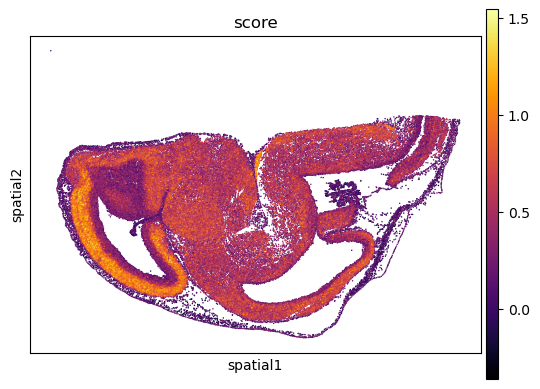

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter1.pdf", bbox_inches="tight")

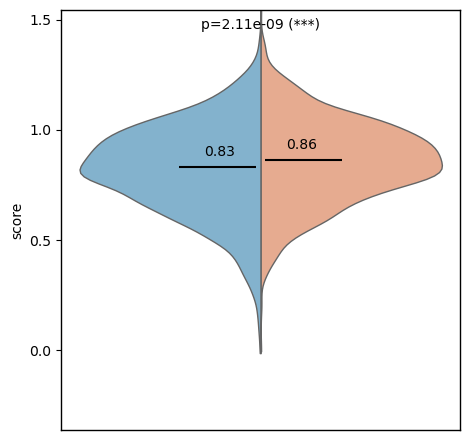

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin1.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### FB RG (Forebrain radial glia)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Forebrain radial glia")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "2"
mask_sc = adata_scanpy.obs["leiden_1.5"].astype(str) == "2"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/4138039861.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


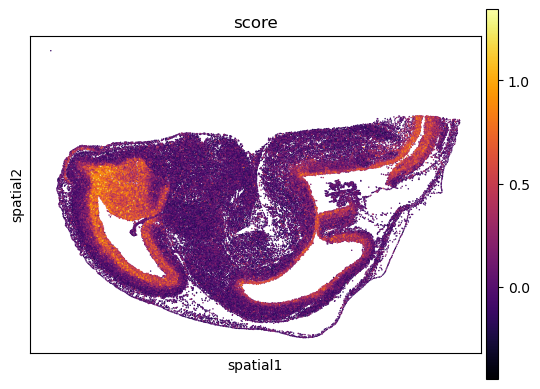

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter2.pdf", bbox_inches="tight")

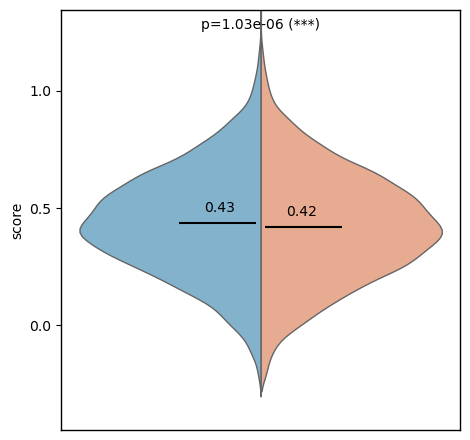

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin2.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Ctx IP (Cortical intermediate progenitor)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Cortical intermediate progenitor")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_4.0"].astype(str) == "6"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "5"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/155313628.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


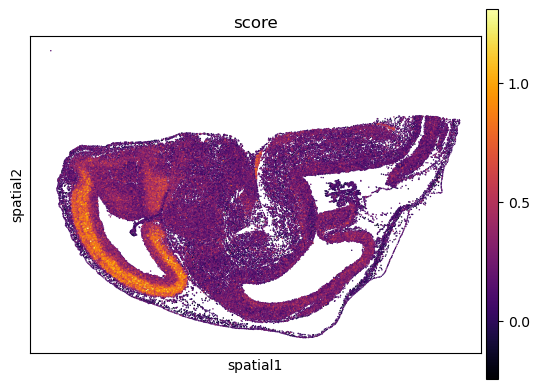

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter3.pdf", bbox_inches="tight")

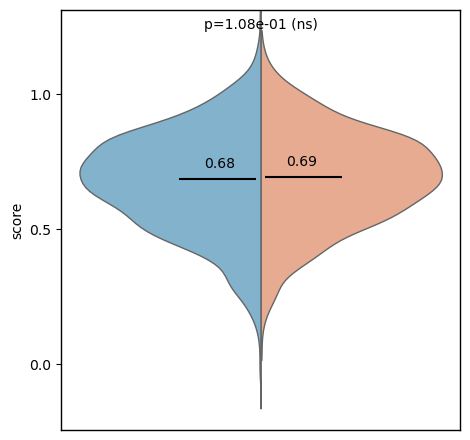

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin3.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### FB (Fibroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Fibroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "5"
mask_sc = adata_scanpy.obs["leiden_3.0"].astype(str) == "2"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2868874372.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


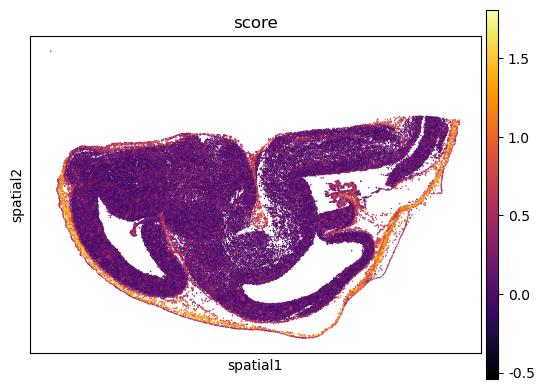

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter4.pdf", bbox_inches="tight")

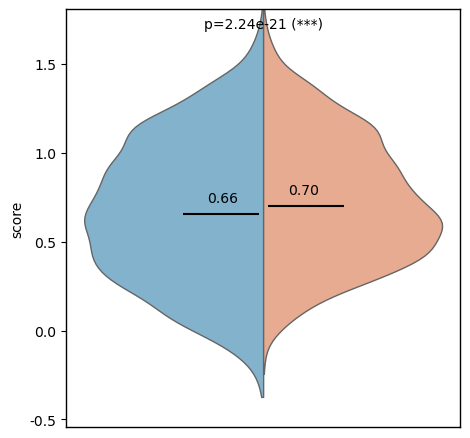

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin4.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB Glu NB (Hindbrain glutamatergic neuroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain glutamatergic neuroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_5.0"].astype(str) == "48"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "24"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/3087718920.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


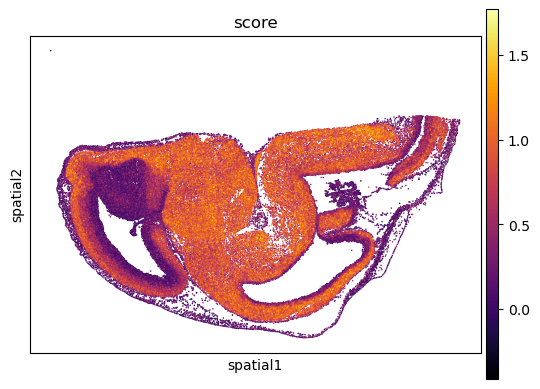

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter5.pdf", bbox_inches="tight")

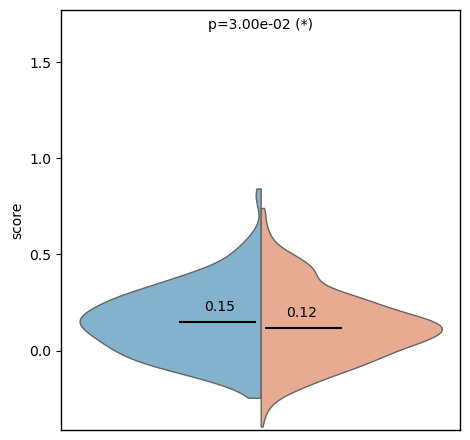

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin5.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB NB (Hindbrain neuroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain neuroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_3.5"].astype(str) == "0"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "4"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/1641073823.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


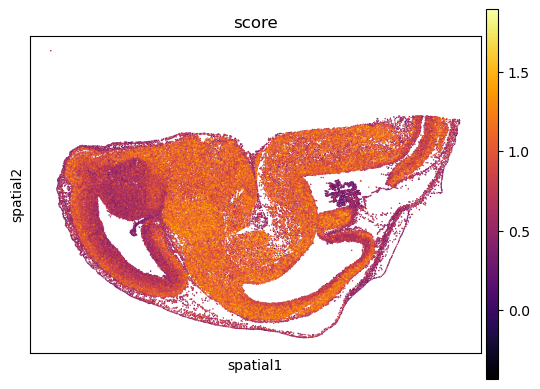

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter6.pdf", bbox_inches="tight")

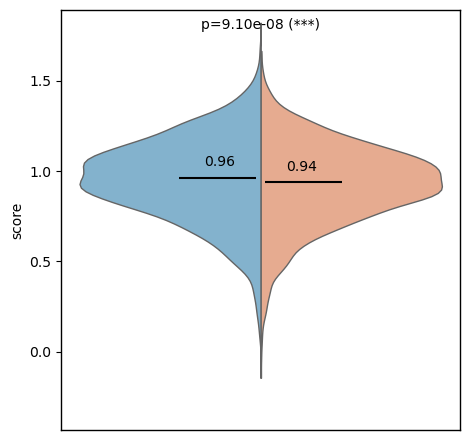

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin6.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB GB (Hindbrain glioblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain glioblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_2.0"].astype(str) == "14"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "13"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2538700838.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


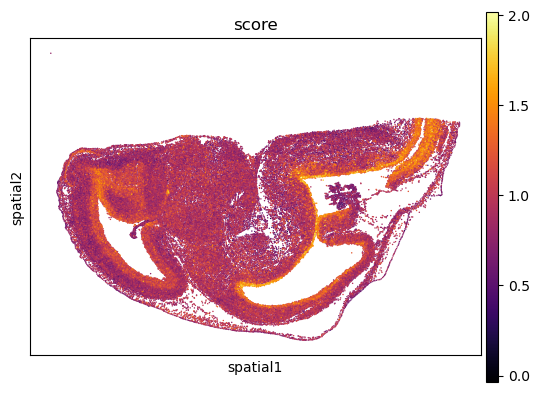

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter7.pdf", bbox_inches="tight")

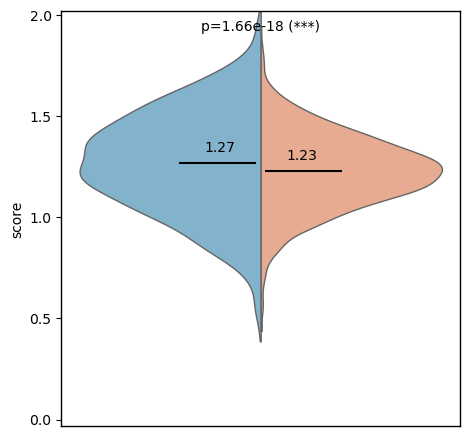

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin7.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Mixed GB (Mixed region glioblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Mixed region glioblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "9"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "6"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/1007084332.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


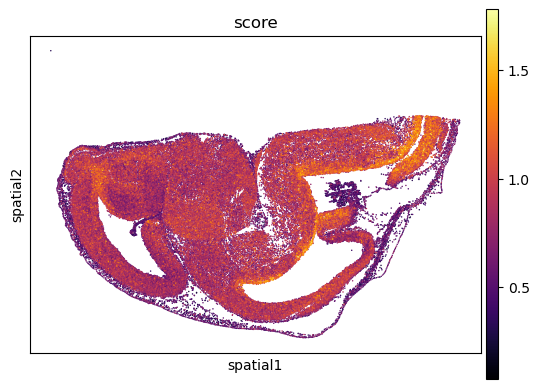

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter8.pdf", bbox_inches="tight")

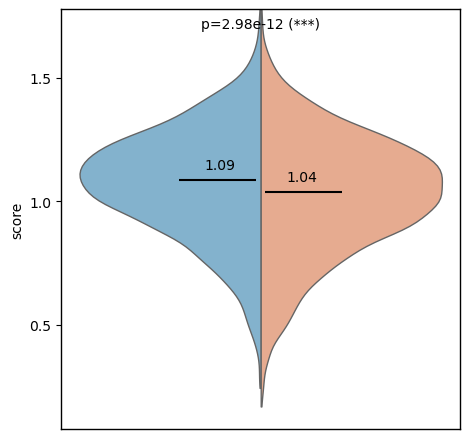

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin8.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### RBC (Erythrocyte)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Erythrocyte")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_1.0"].astype(str) == "12"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "7"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/703870670.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


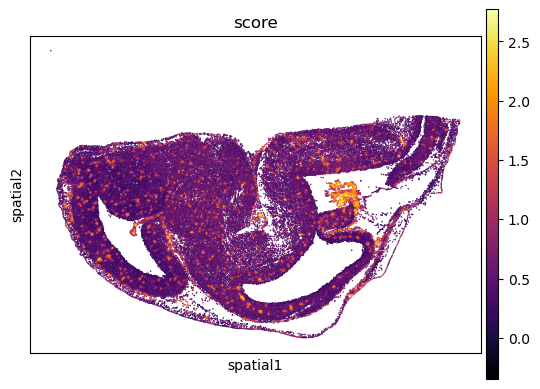

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   # 중요
)

# colorbar 축은 보통 마지막 axis
cax = fig.axes[-1]

# 0.5 step tick 강제
cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter9.pdf", bbox_inches="tight")

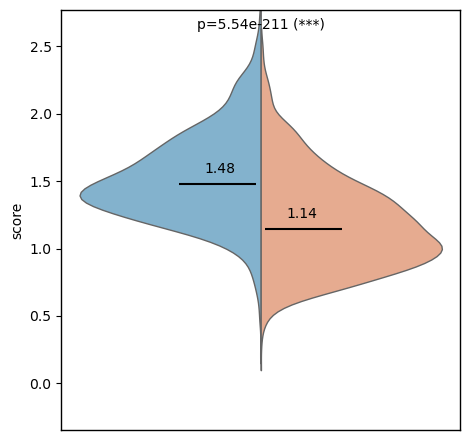

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

# 0.5 step tick 강제
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin9.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()
